## ML Practice Questions

## 1. . Predict company profit from advertising & operational spend.
 Dataset: 50_Startups.csv (columns: R&D Spend, Administration, Marketing Spend,
State, Profit)

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler,OneHotEncoder,LabelEncoder
from sklearn.linear_model import LinearRegression,LogisticRegression
print('Imported')

Imported


In [19]:
df1=pd.read_csv('./50_Startups.csv')

In [20]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.5 KB


In [21]:
df1.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [22]:
df1.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [23]:
X=df1.drop('Profit',axis=1)
y=df1['Profit']

In [24]:
X['State'] = X['State'].map({
    'California': 0,
    'Florida': 1,
    'New York': 2
})
df1.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)
model=LinearRegression()
model.fit(X_train,y_train)
print('Trained')

Trained


In [26]:
y_pred=model.predict(X_test)


In [32]:
print(f'R2 score: {metrics.r2_score(y_test,y_pred):.2f}')
print(f'Mean squared error : {metrics.mean_squared_error(y_test,y_pred):.2f}')
print(f'Root mean squared error: {np.sqrt(metrics.mean_squared_error(y_test,y_pred)):.2f}')

R2 score: 0.90
Mean squared error : 80929465.49
Root mean squared error: 8996.08


In [33]:
compare=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})

In [34]:
compare.head()

,Actual,Predicted
13,134307.35,126720.661507
39,81005.76,84909.089619
30,99937.59,98890.318549
45,64926.08,46479.312402
17,125370.37,129113.183188


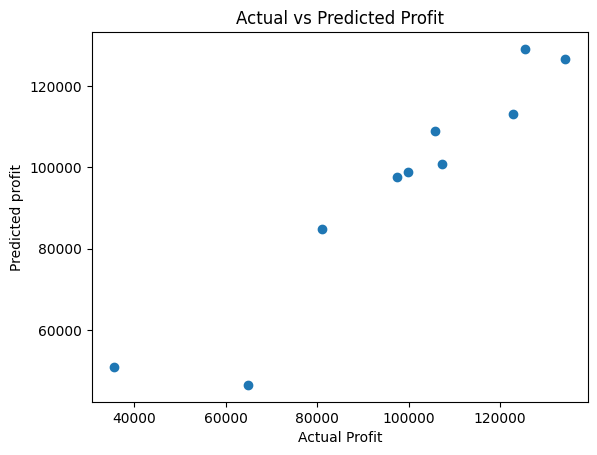

In [36]:
plt.scatter(y_test,y_pred)
plt.xlabel('Actual Profit')
plt.ylabel('Predicted profit')
plt.title('Actual vs Predicted Profit')
plt.show()

##  Q2. Analyse how TV advertising budget affects sales revenue. 
 Dataset: advertising 8.csv (columns: TV_Advertising_Budget, Sales)
Write a Python program to:

In [39]:
df2=pd.read_csv('./advertising 8.csv')

In [40]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   TV_Advertising_Budget  60 non-null     int64
 1   Sales                  60 non-null     int64
dtypes: int64(2)
memory usage: 1.1 KB


In [41]:
df2.head()

,TV_Advertising_Budget,Sales
0,50,12
1,70,15
2,90,18
3,110,22
4,130,25


In [43]:
df2.isnull().sum()

TV_Advertising_Budget    0
Sales                    0
dtype: int64

In [44]:
X=df2.drop('Sales',axis=1)
y=df2['Sales']

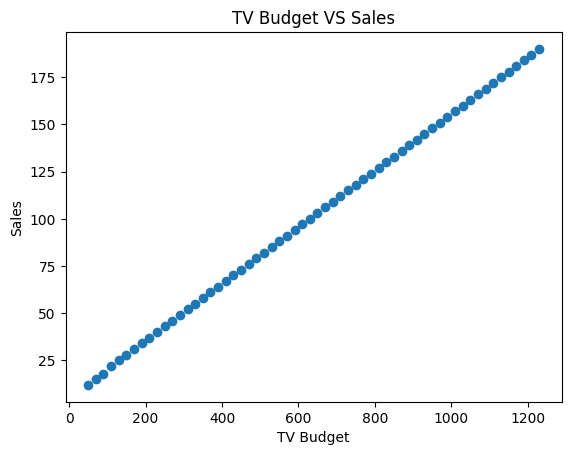

In [46]:
plt.scatter(
    df2['TV_Advertising_Budget'],
    df2['Sales']
)
plt.xlabel('TV Budget')
plt.ylabel('Sales')
plt.title('TV Budget VS Sales')
plt.show()

In [47]:
X_train, X_test, y_train, y_test= train_test_split(
    X,y,test_size=0.2, random_state=42
)
model=LinearRegression()
model.fit(X_train,y_train)
print('Trained')

Trained


In [51]:
print(f'Slope: {model.coef_}')
print(f'Intercept : {model.intercept_}')

Slope: [0.15020474]
Intercept : 5.3311369600681076


In [53]:
y_pred=model.predict(X_test)
print(f'R2 score : {metrics.r2_score(y_test,y_pred)}')
print(f'Mean Squared Error: {metrics.mean_squared_error(y_test,y_pred)}')
print(f'Root Mean Squared Error : {np.sqrt(metrics.mean_squared_error(y_test,y_pred))}')

R2 score : 0.9999814664420835
Mean Squared Error: 0.06378118028539828
Root Mean Squared Error : 0.25254936207679934


In [54]:
compare=pd.DataFrame({
    'Actual':y_test,
    'Predicted':y_pred
})
compare.head()

,Actual,Predicted
0,12,12.841374
5,28,27.861848
36,121,120.988789
45,148,148.025642
13,52,51.894607


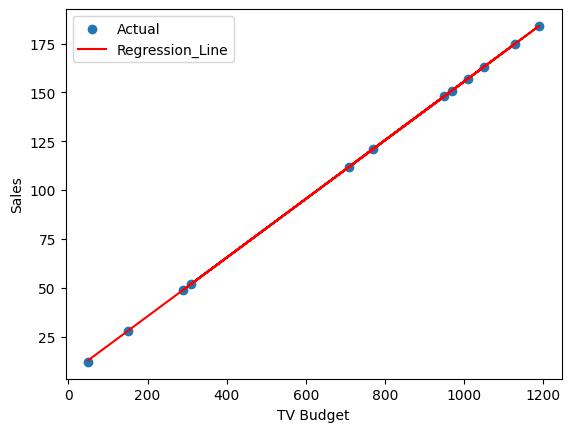

In [55]:
plt.scatter(X_test,y_test,label='Actual')
plt.plot(X_test,y_pred,label='Regression_Line',color='Red')
plt.xlabel('TV Budget')
plt.ylabel('Sales')
plt.legend()
plt.show()

## 3.Predict car selling price using multiple features.
 Dataset: car.csv (columns: Car_Name, Year, Selling_Price, Present_Price,
Kms_Driven, Fuel_Type, Seller_Type, Transmission, Owner)
Write a Python program to:


In [4]:

data = {
    'Car_Name':['Swift','City','i20','Creta','Baleno'],
    'Year':[2018,2016,2019,2020,2017],
    'Selling_Price':[5.5,7.2,6.8,11.5,5.9],
    'Present_Price':[7.0,9.5,8.0,13.0,7.5],
    'Kms_Driven':[30000,45000,25000,15000,38000],
    'Fuel_Type':['Petrol','Diesel','Petrol','Diesel','Petrol'],
    'Seller_Type':['Dealer','Dealer','Individual','Dealer','Individual'],
    'Transmission':['Manual','Manual','Automatic','Manual','Manual'],
    'Owner':[0,1,0,0,1]
}

df3 = pd.DataFrame(data)

df3.to_csv('car.csv', index=False)

print(df3)

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0    Swift  2018            5.5            7.0       30000    Petrol   
1     City  2016            7.2            9.5       45000    Diesel   
2      i20  2019            6.8            8.0       25000    Petrol   
3    Creta  2020           11.5           13.0       15000    Diesel   
4   Baleno  2017            5.9            7.5       38000    Petrol   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      1  
2  Individual    Automatic      0  
3      Dealer       Manual      0  
4  Individual       Manual      1  


In [6]:
df3.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,Swift,2018,5.5,7.0,30000,Petrol,Dealer,Manual,0
1,City,2016,7.2,9.5,45000,Diesel,Dealer,Manual,1
2,i20,2019,6.8,8.0,25000,Petrol,Individual,Automatic,0
3,Creta,2020,11.5,13.0,15000,Diesel,Dealer,Manual,0
4,Baleno,2017,5.9,7.5,38000,Petrol,Individual,Manual,1


In [7]:
df3.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [8]:
df3.drop('Car_Name',inplace=True,axis=1)

In [9]:
df3['Car_Age']=2026-df3['Year']
df3.drop('Year',inplace=True,axis=1)

In [13]:
le=LabelEncoder()
for col in ['Fuel_Type','Seller_Type','Transmission']:
    df3[col]=le.fit_transform(df3[col])



In [15]:
X=df3.drop('Selling_Price',axis=1)
y=df3['Selling_Price']

In [16]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [17]:
model=LinearRegression()
model.fit(X_train,y_train)
print('Trained')

Trained


In [21]:
y_pred=model.predict(X_test)

In [22]:
print("R2 Score:", metrics.r2_score(y_test, y_pred))

print(
    "RMSE:",
    np.sqrt(metrics.mean_squared_error(y_test, y_pred))
)

R2 Score: nan
RMSE: 0.08242050128400624


C:\Users\Dell\Desktop\INTERNSHIPS\Labmentix(DS_AI_ML)\Mini Project\1\.venv\Lib\site-packages\sklearn\metrics\_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [23]:
compare = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(compare.head())

   Actual  Predicted
1     7.2   7.117579


## Q4. Predict insurance medical charges based on patient data.
 Dataset: insurance.csv (columns: age, sex, bmi, children, smoker, region, charges)
Write a Python program to:

In [24]:

data = {
    'age': [19, 25, 32, 45, 50, 28, 37, 60, 22, 41],
    'sex': ['female', 'male', 'male', 'female', 'male',
            'female', 'male', 'female', 'male', 'female'],
    'bmi': [27.9, 22.5, 30.1, 25.8, 29.4,
            21.7, 33.2, 28.5, 24.3, 31.0],
    'children': [0, 1, 2, 3, 2, 0, 1, 4, 0, 2],
    'smoker': ['yes', 'no', 'no', 'yes', 'yes',
               'no', 'no', 'yes', 'no', 'yes'],
    'region': ['southwest', 'southeast', 'northwest',
               'northeast', 'southwest',
               'northwest', 'southeast',
               'northeast', 'southwest', 'northwest'],
    'charges': [16884, 3200, 5400, 21000, 25000,
                2800, 6500, 30000, 2200, 19000]
}

df4 = pd.DataFrame(data)

print(df4)

df4.to_csv("insurance.csv", index=False)

   age     sex   bmi  children smoker     region  charges
0   19  female  27.9         0    yes  southwest    16884
1   25    male  22.5         1     no  southeast     3200
2   32    male  30.1         2     no  northwest     5400
3   45  female  25.8         3    yes  northeast    21000
4   50    male  29.4         2    yes  southwest    25000
5   28  female  21.7         0     no  northwest     2800
6   37    male  33.2         1     no  southeast     6500
7   60  female  28.5         4    yes  northeast    30000
8   22    male  24.3         0     no  southwest     2200
9   41  female  31.0         2    yes  northwest    19000


In [26]:
df4.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.9,0,yes,southwest,16884
1,25,male,22.5,1,no,southeast,3200
2,32,male,30.1,2,no,northwest,5400
3,45,female,25.8,3,yes,northeast,21000
4,50,male,29.4,2,yes,southwest,25000


In [27]:
df4.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [28]:
le=LabelEncoder()
for col in ['sex','smoker','region']:
    df4[col]=le.fit_transform(df4[col])

In [29]:
X=df4.drop('charges',axis=1)
y=df4['charges']

In [31]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [32]:
model=LinearRegression()
model.fit(X_train,y_train)
print('Trained')

Trained


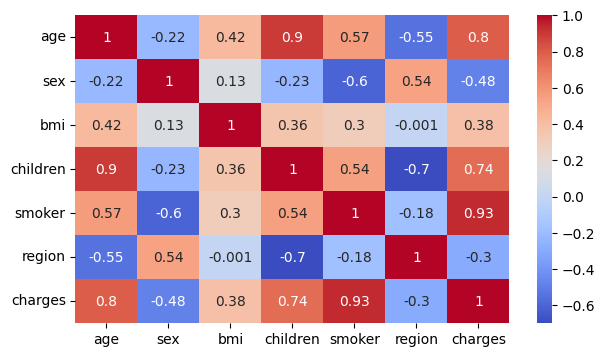

In [35]:
plt.figure(figsize=(7,4))

sns.heatmap(
    df4.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [36]:
y_pred=model.predict(X_test)

In [37]:
print("R2 Score:", metrics.r2_score(y_test, y_pred))

print(
    "RMSE:",
    np.sqrt(metrics.mean_squared_error(y_test, y_pred))
)

R2 Score: -36.670990566414766
RMSE: 3068.834899697879


In [38]:
compare = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(compare.head())

   Actual    Predicted
8    2200  5483.633320
1    3200  6037.824431


In [41]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("R2:", metrics.r2_score(y_test, y_pred))
print("Predictions:", y_pred)
print("Actual:", y_test.values)

Train size: (8, 6)
Test size: (2, 6)
R2: -36.670990566414766
Predictions: [5483.63331993 6037.8244314 ]
Actual: [2200 3200]


## 5. Predict student academic performance index.
 Dataset: Student_Performance.csv (columns: Hours Studied, Previous Scores,
Extracurricular Activities, Sleep Hours, Sample Question Papers Practiced, Performance
Index)
Write a Python program to:


In [2]:

data = {
    'Hours Studied': [2,4,6,8,3,5,7,9,1,10],
    'Previous Scores': [50,60,70,80,55,65,75,85,45,90],
    'Extracurricular Activities': ['Yes','No','Yes','Yes','No',
                                   'No','Yes','Yes','No','Yes'],
    'Sleep Hours': [6,7,8,7,6,8,7,9,5,8],
    'Sample Question Papers Practiced': [1,2,3,4,1,2,3,5,0,6],
    'Performance Index': [45,55,68,80,50,62,74,88,40,95]
}

df5 = pd.DataFrame(data)

df5.to_csv("Student_Performance.csv", index=False)

print(df5)

   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              2               50                        Yes            6   
1              4               60                         No            7   
2              6               70                        Yes            8   
3              8               80                        Yes            7   
4              3               55                         No            6   
5              5               65                         No            8   
6              7               75                        Yes            7   
7              9               85                        Yes            9   
8              1               45                         No            5   
9             10               90                        Yes            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1                 45  
1                                 2   

In [4]:
df5.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,2,50,Yes,6,1,45
1,4,60,No,7,2,55
2,6,70,Yes,8,3,68
3,8,80,Yes,7,4,80
4,3,55,No,6,1,50


In [5]:
df5.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [6]:
le=LabelEncoder()
df5['Extracurricular Activities']=le.fit_transform(df5['Extracurricular Activities'])

In [7]:
X=df5.drop('Performance Index',axis=1)
y=df5['Performance Index']

In [8]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [9]:
model=LinearRegression()
model.fit(X_train,y_train)
print('Trained')

Trained


In [10]:
y_pred=model.predict(X_test)

In [11]:
print("R2 Score:", metrics.r2_score(y_test, y_pred))

print(
    "RMSE:",
    np.sqrt(metrics.mean_squared_error(y_test, y_pred))
)

R2 Score: 0.926755294011504
RMSE: 2.0297819370200583


In [12]:
compare = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print(compare)

   Actual  Predicted
8      40  38.130967
1      55  57.178703


## Q6. Predict whether a user will purchase a product based on age
& salary.
 Dataset: Social_Network_Ads_logistic.csv (columns: User ID, Gender, Age,
EstimatedSalary, Purchased)
Write a Python program to

In [2]:
df6=pd.read_csv('./Social_Network_Ads.csv')
df6.info()


<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 17.7 KB


In [3]:
df6.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df6.drop('User ID',axis=1,inplace=True)

In [5]:
le=LabelEncoder()
df6['Gender']=le.fit_transform(df6['Gender'])

In [6]:
X=df6[['Age','EstimatedSalary']]
y=df6['Purchased']

In [7]:
sc=StandardScaler()
sc.fit_transform(X)

array([[-1.78179743, -1.49004624],
       [-0.25358736, -1.46068138],
       [-1.11320552, -0.78528968],
       [-1.01769239, -0.37418169],
       [-1.78179743,  0.18375059],
       [-1.01769239, -0.34481683],
       [-1.01769239,  0.41866944],
       [-0.54012675,  2.35674998],
       [-1.20871865, -1.07893824],
       [-0.25358736, -0.13926283],
       [-1.11320552,  0.30121002],
       [-1.11320552, -0.52100597],
       [-1.6862843 ,  0.47739916],
       [-0.54012675, -1.51941109],
       [-1.87731056,  0.35993973],
       [-0.82666613,  0.30121002],
       [ 0.89257019, -1.3138571 ],
       [ 0.70154394, -1.28449224],
       [ 0.79705706, -1.22576253],
       [ 0.98808332, -1.19639767],
       [ 0.70154394, -1.40195167],
       [ 0.89257019, -0.60910054],
       [ 0.98808332, -0.84401939],
       [ 0.70154394, -1.40195167],
       [ 0.79705706, -1.37258681],
       [ 0.89257019, -1.46068138],
       [ 1.08359645, -1.22576253],
       [ 0.89257019, -1.16703281],
       [-0.82666613,

In [8]:
X_train, X_test,y_train, y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [12]:
model=LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
y_pred=model.predict(X_test)

In [14]:
print(f'Accuracy: {metrics.accuracy_score(y_test,y_pred)}')

Accuracy: 0.8875


In [16]:
cm = metrics.confusion_matrix(y_test, y_pred)

print(cm)

[[50  2]
 [ 7 21]]


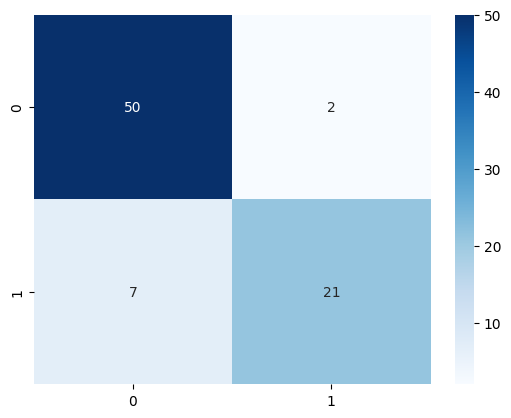

In [17]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

In [19]:
print(
    metrics.classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92        52
           1       0.91      0.75      0.82        28

    accuracy                           0.89        80
   macro avg       0.90      0.86      0.87        80
weighted avg       0.89      0.89      0.88        80



## 7. Predict employee attrition (will they leave the company?).
 Dataset: Logistic-HR-Employee-Attrition.csv (target column: Attrition — Yes/No)
Write a Python program to

In [21]:
df7=pd.read_csv('./Employee_Attrition_Dataset.csv')

In [22]:
df7.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EmployeeID             10000 non-null  str    
 1   Age                    10000 non-null  int64  
 2   Department             10000 non-null  str    
 3   JobLevel               10000 non-null  int64  
 4   YearsAtCompany         10000 non-null  int64  
 5   MonthlyIncome          10000 non-null  int64  
 6   JobSatisfaction        10000 non-null  int64  
 7   WorkLifeBalance        10000 non-null  int64  
 8   OverTime               10000 non-null  str    
 9   DistanceFromHome       10000 non-null  float64
 10  PromotionLast5Years    10000 non-null  str    
 11  PerformanceRating      10000 non-null  int64  
 12  TrainingHoursLastYear  10000 non-null  int64  
 13  Attrition              10000 non-null  str    
dtypes: float64(1), int64(8), str(5)
memory usage: 1.3 MB


In [23]:
df7.head()


,EmployeeID,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,EMP0000,42,Sales,3,9,9866,4,1,No,24.5,Yes,4,19,No
1,EMP0001,36,Sales,3,7,8958,3,3,No,10.0,No,2,13,No
2,EMP0002,44,Sales,4,16,11716,4,3,No,4.0,No,4,13,No
3,EMP0003,53,Finance,4,30,17061,5,3,No,7.1,No,3,20,No
4,EMP0004,35,HR,2,4,5738,2,3,No,8.4,No,2,15,No


In [24]:
df7.isnull().sum()

EmployeeID               0
Age                      0
Department               0
JobLevel                 0
YearsAtCompany           0
MonthlyIncome            0
JobSatisfaction          0
WorkLifeBalance          0
OverTime                 0
DistanceFromHome         0
PromotionLast5Years      0
PerformanceRating        0
TrainingHoursLastYear    0
Attrition                0
dtype: int64

In [29]:

le = LabelEncoder()

for col in df7.columns:
    if df7[col].dtype == 'object':
        df7[col] = le.fit_transform(df7[col])

In [30]:
df7.drop('EmployeeID', axis=1, inplace=True)

KeyError: "['EmployeeID'] not found in axis"

In [31]:
df7.head()

,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,42,Sales,3,9,9866,4,1,0,24.5,Yes,4,19,0
1,36,Sales,3,7,8958,3,3,0,10.0,No,2,13,0
2,44,Sales,4,16,11716,4,3,0,4.0,No,4,13,0
3,53,Finance,4,30,17061,5,3,0,7.1,No,3,20,0
4,35,HR,2,4,5738,2,3,0,8.4,No,2,15,0


In [39]:
df7['Department']=le.fit_transform(df7['Department'])
df7['PromotionLast5Years']=le.fit_transform(df7['PromotionLast5Years'])

In [40]:
df7.head()

,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear,Attrition
0,42,6,3,9,9866,4,1,0,24.5,1,4,19,0
1,36,6,3,7,8958,3,3,0,10.0,0,2,13,0
2,44,6,4,16,11716,4,3,0,4.0,0,4,13,0
3,53,1,4,30,17061,5,3,0,7.1,0,3,20,0
4,35,2,2,4,5738,2,3,0,8.4,0,2,15,0


In [41]:
X=df7.drop('Attrition',axis=1)
y=df7['Attrition']
X.head()

,Age,Department,JobLevel,YearsAtCompany,MonthlyIncome,JobSatisfaction,WorkLifeBalance,OverTime,DistanceFromHome,PromotionLast5Years,PerformanceRating,TrainingHoursLastYear
0,42,6,3,9,9866,4,1,0,24.5,1,4,19
1,36,6,3,7,8958,3,3,0,10.0,0,2,13
2,44,6,4,16,11716,4,3,0,4.0,0,4,13
3,53,1,4,30,17061,5,3,0,7.1,0,3,20
4,35,2,2,4,5738,2,3,0,8.4,0,2,15


In [44]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [46]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=.2,random_state=42
)

In [47]:
model=LogisticRegression()

model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [48]:
y_pred=model.predict(X_test)

In [50]:
print(f'Accuracy : {metrics.accuracy_score(y_test,y_pred)}')

Accuracy : 0.9065


In [51]:
cm = metrics.confusion_matrix(y_test, y_pred)

print(cm)

[[1813    0]
 [ 187    0]]


In [52]:
coef = pd.DataFrame({
    'Feature': df7.drop('Attrition', axis=1).columns,
    'Coefficient': model.coef_[0]
})

print(coef.sort_values(
    by='Coefficient',
    ascending=False
))

                  Feature  Coefficient
7                OverTime     0.227859
4           MonthlyIncome     0.106461
1              Department     0.049691
0                     Age     0.021271
11  TrainingHoursLastYear    -0.005240
8        DistanceFromHome    -0.007438
9     PromotionLast5Years    -0.093764
10      PerformanceRating    -0.115980
3          YearsAtCompany    -0.120905
6         WorkLifeBalance    -0.245710
2                JobLevel    -0.248964
5         JobSatisfaction    -0.314060


## 8. Predict Titanic passenger survival.
 Dataset: titanic.csv (columns: PassengerId, Survived, Pclass, Name, Sex, Age, SibSp,
Parch, Ticket, Fare, Cabin, Embarked)
Write a Python program to:

In [53]:
df8=pd.read_csv('./titanic.csv')

In [54]:
df8.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [55]:
df8.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [56]:
df8.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [58]:
df8['Age'] = df8['Age'].fillna(
    df8['Age'].median()
)
df8.drop('Cabin',axis=1,inplace=True)

df8['Embarked'] = df8['Embarked'].fillna(
    df8['Embarked'].mode()[0]
)

In [59]:
df8.drop(
    ['PassengerId','Name','Ticket'],
    axis=1,
    inplace=True
)

In [60]:
df8.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [61]:
le=LabelEncoder()

In [62]:
df8['Sex']=le.fit_transform(df8['Sex'])
df8['Embarked']=le.fit_transform(df8['Embarked'])

In [63]:
df8.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,2
1,1,1,0,38.0,1,0,71.2833,0
2,1,3,0,26.0,0,0,7.9250,2
3,1,1,0,35.0,1,0,53.1000,2
4,0,3,1,35.0,0,0,8.0500,2


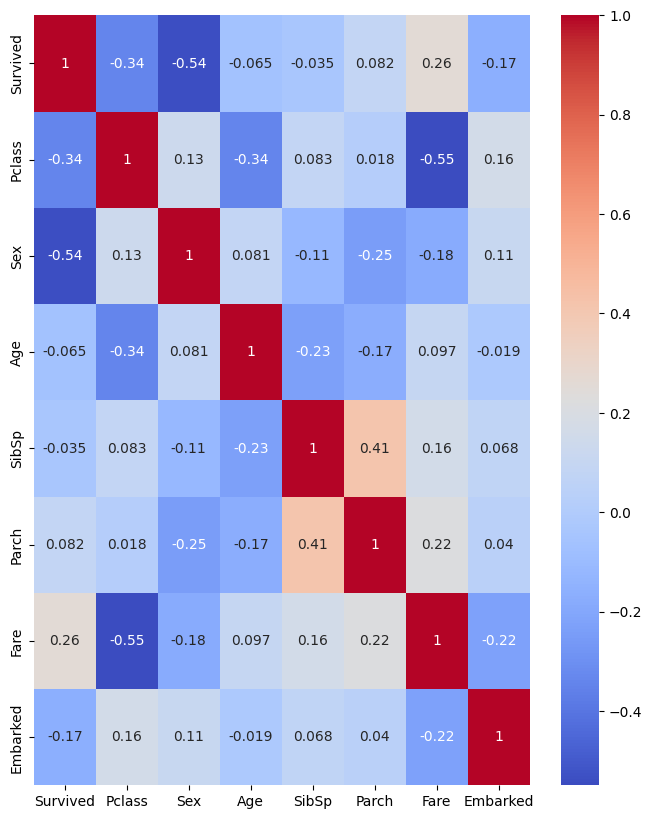

In [64]:
plt.figure(figsize=(8,10))
sns.heatmap(
    df8.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.show()

In [65]:
X=df8.drop('Survived',axis=1)
y=df8['Survived']

In [67]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [69]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [70]:
y_pred=model.predict(X_test)

In [71]:
print(f'Acuracy:{metrics.accuracy_score(y_test,y_pred)}')

Acuracy:0.8044692737430168


In [73]:
print(
    metrics.classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [74]:
coef = pd.DataFrame({
    'Feature': df8.drop(
        'Survived',
        axis=1
    ).columns,
    
    'Coefficient': model.coef_[0]
})

print(coef)

    Feature  Coefficient
0    Pclass    -0.792517
1       Sex    -1.285813
2       Age    -0.395757
3     SibSp    -0.328189
4     Parch    -0.100018
5      Fare     0.121214
6  Embarked    -0.174770


## 9. Predict loan approval using applicant data
 Dataset: logistic_loan_approve.csv
Write a Python program to:


In [2]:

data = {
    'Gender':['Male','Female','Male','Male','Female',
              'Male','Female','Male','Female','Male'],
    
    'Married':['Yes','No','Yes','Yes','No',
               'Yes','No','Yes','No','Yes'],
    
    'ApplicantIncome':[5000,3000,7000,4500,2500,
                       8000,3500,6000,2800,7500],
    
    'LoanAmount':[120,80,150,100,70,
                  180,90,130,75,160],
    
    'Credit_History':[1,1,1,0,1,
                      1,0,1,1,1],
    
    'Property_Area':['Urban','Rural','Urban','Semiurban',
                     'Rural','Urban','Semiurban',
                     'Urban','Rural','Semiurban'],
    
    'Loan_Status':['Y','N','Y','N','N',
                   'Y','N','Y','N','Y']
}

df9 = pd.DataFrame(data)

df9.to_csv(
    "logistic_loan_approve.csv",
    index=False
)

print(df9)

   Gender Married  ApplicantIncome  LoanAmount  Credit_History Property_Area  \
0    Male     Yes             5000         120               1         Urban   
1  Female      No             3000          80               1         Rural   
2    Male     Yes             7000         150               1         Urban   
3    Male     Yes             4500         100               0     Semiurban   
4  Female      No             2500          70               1         Rural   
5    Male     Yes             8000         180               1         Urban   
6  Female      No             3500          90               0     Semiurban   
7    Male     Yes             6000         130               1         Urban   
8  Female      No             2800          75               1         Rural   
9    Male     Yes             7500         160               1     Semiurban   

  Loan_Status  
0           Y  
1           N  
2           Y  
3           N  
4           N  
5           Y  
6      

In [3]:
df9.isnull().sum()

Gender             0
Married            0
ApplicantIncome    0
LoanAmount         0
Credit_History     0
Property_Area      0
Loan_Status        0
dtype: int64

In [7]:
le=LabelEncoder()
df9['Gender']=le.fit_transform(df9['Gender'])
df9['Married']=le.fit_transform(df9['Married'])
df9['Property_Area']=le.fit_transform(df9['Property_Area'])
df9['Loan_Status']=le.fit_transform(df9['Loan_Status'])


In [8]:
df9.head()

,Gender,Married,ApplicantIncome,LoanAmount,Credit_History,Property_Area,Loan_Status
0,1,1,5000,120,1,2,1
1,0,0,3000,80,1,0,0
2,1,1,7000,150,1,2,1
3,1,1,4500,100,0,1,0
4,0,0,2500,70,1,0,0


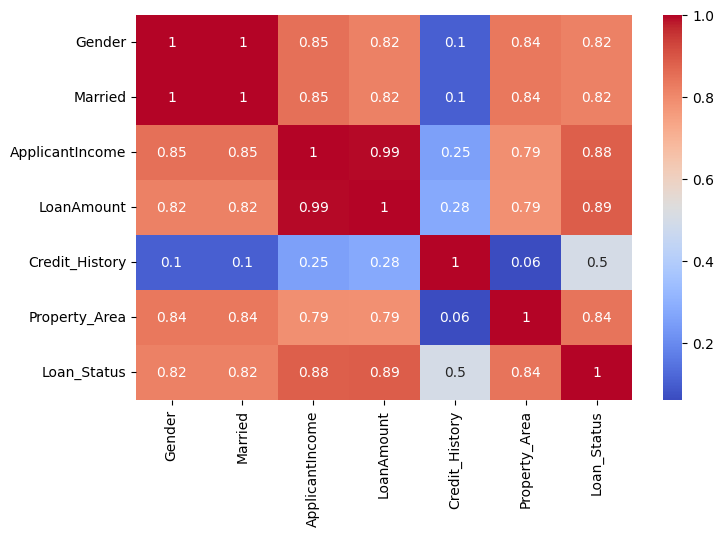

In [9]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df9.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [10]:
X=df9.drop('Loan_Status',axis=1)
y=df9['Loan_Status']

In [12]:
sc=StandardScaler()
sc.fit_transform(X)

array([[ 0.81649658,  0.81649658,  0.01028199,  0.12282756,  0.5       ,
         1.08347268],
       [-1.22474487, -1.22474487, -1.0179175 , -0.96897294,  0.5       ,
        -1.32424438],
       [ 0.81649658,  0.81649658,  1.03848149,  0.94167792,  0.5       ,
         1.08347268],
       [ 0.81649658,  0.81649658, -0.24676788, -0.42307269, -2.        ,
        -0.12038585],
       [-1.22474487, -1.22474487, -1.27496738, -1.24192306,  0.5       ,
        -1.32424438],
       [ 0.81649658,  0.81649658,  1.55258124,  1.76052829,  0.5       ,
         1.08347268],
       [-1.22474487, -1.22474487, -0.76086763, -0.69602281, -2.        ,
        -0.12038585],
       [ 0.81649658,  0.81649658,  0.52438174,  0.39577768,  0.5       ,
         1.08347268],
       [-1.22474487, -1.22474487, -1.12073745, -1.105448  ,  0.5       ,
        -1.32424438],
       [ 0.81649658,  0.81649658,  1.29553137,  1.21462805,  0.5       ,
        -0.12038585]])

In [13]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [17]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
print('Trained')

Trained


In [18]:
y_pred=model.predict(X_test)

In [19]:
print(f'Accuracy:{metrics.accuracy_score(y_test,y_pred)}')

Accuracy:1.0


## Q10. Build a credit card fraud detection classifier.
 Dataset: Logisitc_Creditcard.csv (large file — sample 10,000 rows using
nrows=10000)
Write a Python program to:

In [20]:
df10=pd.read_csv('./creditcard.csv')

In [21]:
df10.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [22]:
df10.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [23]:
print(df10['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [24]:
print(df10.isnull().sum())

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [25]:
X = df10.drop('Class', axis=1)

y = df10['Class']

In [26]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
model = LogisticRegression(
    max_iter=1000
)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
y_pred = model.predict(X_test)

print(y_pred)

[0 0 0 ... 0 0 0]


In [30]:
print(
    "Accuracy:",
    metrics.accuracy_score(y_test, y_pred)
)

Accuracy: 0.9991573329588147


In [31]:
cm = metrics.confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[56851    13]
 [   35    63]]


In [32]:
print(
    metrics.classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## classify whether a user purchased a product using KNN.
 Dataset: Social_Network_Ads_logistic.csv (Age, EstimatedSalary → Purchased)
Write a Python program to:

In [33]:
df11=pd.read_csv('./Social_Network_Ads.csv')

In [34]:
df11.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 17.7 KB


In [35]:
df11.head()


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [36]:
df11.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [40]:
X=df11[['Age','EstimatedSalary']]
y=df11['Purchased']

In [41]:
sc=StandardScaler()

In [42]:
sc.fit_transform(X)

array([[-1.78179743, -1.49004624],
       [-0.25358736, -1.46068138],
       [-1.11320552, -0.78528968],
       [-1.01769239, -0.37418169],
       [-1.78179743,  0.18375059],
       [-1.01769239, -0.34481683],
       [-1.01769239,  0.41866944],
       [-0.54012675,  2.35674998],
       [-1.20871865, -1.07893824],
       [-0.25358736, -0.13926283],
       [-1.11320552,  0.30121002],
       [-1.11320552, -0.52100597],
       [-1.6862843 ,  0.47739916],
       [-0.54012675, -1.51941109],
       [-1.87731056,  0.35993973],
       [-0.82666613,  0.30121002],
       [ 0.89257019, -1.3138571 ],
       [ 0.70154394, -1.28449224],
       [ 0.79705706, -1.22576253],
       [ 0.98808332, -1.19639767],
       [ 0.70154394, -1.40195167],
       [ 0.89257019, -0.60910054],
       [ 0.98808332, -0.84401939],
       [ 0.70154394, -1.40195167],
       [ 0.79705706, -1.37258681],
       [ 0.89257019, -1.46068138],
       [ 1.08359645, -1.22576253],
       [ 0.89257019, -1.16703281],
       [-0.82666613,

In [44]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [45]:
for i in range(1,15):
    model = KNeighborsClassifier(n_neighbors = i)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"Accuracy Score: with {i} is {metrics.accuracy_score(y_test,y_pred)}")

Accuracy Score: with 1 is 0.8125
Accuracy Score: with 2 is 0.7625
Accuracy Score: with 3 is 0.8
Accuracy Score: with 4 is 0.8
Accuracy Score: with 5 is 0.825
Accuracy Score: with 6 is 0.775
Accuracy Score: with 7 is 0.8125
Accuracy Score: with 8 is 0.775
Accuracy Score: with 9 is 0.8
Accuracy Score: with 10 is 0.775
Accuracy Score: with 11 is 0.8
Accuracy Score: with 12 is 0.775
Accuracy Score: with 13 is 0.75
Accuracy Score: with 14 is 0.7625


In [46]:
model=KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [47]:
y_pred=model.predict(X_test)

In [48]:
print(f'Accuracy:{metrics.accuracy_score(y_test,y_pred)}')

Accuracy:0.825


In [50]:
cm = metrics.confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[46  6]
 [ 8 20]]


## 12. Predict wine quality using KNN.
 Dataset: winequality.csv (columns: fixed acidity, volatile acidity, ..., quality, Id)
Write a Python program to:

In [51]:
df12=pd.read_csv('./winequality.csv')

In [52]:
df12.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [53]:
df12.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [54]:
df12.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [55]:
df12.drop('Id', axis=1, inplace=True)

In [56]:
X=df12.drop('quality',axis=1)
y=df12['quality']

In [57]:

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [58]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [59]:
for i in range(1,15):
    model=KNeighborsClassifier(n_neighbors=i)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    print(f'{i} ----> {metrics.accuracy_score(y_test,y_pred)}')

1 ----> 0.5764192139737991
2 ----> 0.5327510917030568
3 ----> 0.519650655021834
4 ----> 0.5327510917030568
5 ----> 0.5633187772925764
6 ----> 0.6026200873362445
7 ----> 0.6026200873362445
8 ----> 0.6157205240174672
9 ----> 0.5764192139737991
10 ----> 0.5895196506550219
11 ----> 0.5764192139737991
12 ----> 0.5720524017467249
13 ----> 0.5764192139737991
14 ----> 0.5938864628820961


In [61]:
model=KNeighborsClassifier(n_neighbors=8)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(f'Accuracy:{metrics.accuracy_score(y_test,y_pred)}')

Accuracy:0.6157205240174672


In [62]:
cm = metrics.confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 0  3  3  0  0]
 [ 3 75 17  1  0]
 [ 1 34 55  9  0]
 [ 0  2 13 11  0]
 [ 0  0  1  1  0]]


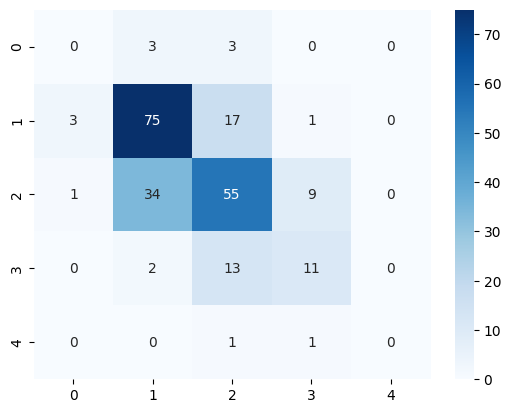

In [63]:
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.show()

In [64]:
print(
    metrics.classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.66      0.78      0.71        96
           6       0.62      0.56      0.59        99
           7       0.50      0.42      0.46        26
           8       0.00      0.00      0.00         2

    accuracy                           0.62       229
   macro avg       0.36      0.35      0.35       229
weighted avg       0.60      0.62      0.60       229



C:\Users\Dell\Desktop\INTERNSHIPS\Labmentix(DS_AI_ML)\Mini Project\1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\Desktop\INTERNSHIPS\Labmentix(DS_AI_ML)\Mini Project\1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Dell\Desktop\INTERNSHIPS\Labmentix(DS_AI_ML)\Mini Project\1\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_d